# FASE 7: ANÁLISIS UNIVARIADO

In [4]:
from google.colab import drive
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Montar Drive
drive.mount('/content/drive', force_remount=False)

# Configuración de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("FASE 7: ANÁLISIS UNIVARIADO")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FASE 7: ANÁLISIS UNIVARIADO


Cargar datos (Fase 6)


In [5]:
print("\n[1/8] Cargando datos...")

df = pd.read_csv('/content/drive/MyDrive/endes-anemia2024-data/processed/06_data_features_selected.csv')

print(f"✓ Datos cargados: {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"✓ Columnas: {list(df.columns)}")


[1/8] Cargando datos...
✓ Datos cargados: 17,418 registros × 4 variables
✓ Columnas: ['HHID', 'anemia_nivel', 'edad_nino', 'edad_madre']


Exploración inicial

In [6]:
print("\n[2/8] EXPLORACIÓN INICIAL")
print("-"*70)
print(f"\nDataset: {df.shape[0]:,} registros × {df.shape[1]} columnas")
print(f"\nValores faltantes:")
print(df.isnull().sum())
print(f"\nTipos de datos:")
print(df.dtypes)


[2/8] EXPLORACIÓN INICIAL
----------------------------------------------------------------------

Dataset: 17,418 registros × 4 columnas

Valores faltantes:
HHID            0
anemia_nivel    0
edad_nino       0
edad_madre      0
dtype: int64

Tipos de datos:
HHID              int64
anemia_nivel      int64
edad_nino       float64
edad_madre      float64
dtype: object


In [7]:
print("\n[3/8] VARIABLE RESPUESTA: anemia_nivel")
print("-"*70)

print(f"\nDistribución:")
print(df['anemia_nivel'].value_counts().sort_index())

print(f"\nPorcentajes:")
print((df['anemia_nivel'].value_counts(normalize=True).sort_index() * 100).round(2))

print(f"\nEstadísticas descriptivas:")
print(df['anemia_nivel'].describe())


[3/8] VARIABLE RESPUESTA: anemia_nivel
----------------------------------------------------------------------

Distribución:
anemia_nivel
1       24
2     1904
3     4336
4    11154
Name: count, dtype: int64

Porcentajes:
anemia_nivel
1     0.14
2    10.93
3    24.89
4    64.04
Name: proportion, dtype: float64

Estadísticas descriptivas:
count    17418.000000
mean         3.528304
std          0.690013
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          4.000000
Name: anemia_nivel, dtype: float64


In [8]:
print("\n[4/8] VARIABLES CONTINUAS - ESTADÍSTICAS")
print("-"*70)

continuas = ['edad_nino', 'edad_madre']

for var in continuas:
    if var in df.columns:
        print(f"\n{var.upper()}:")
        print(f"  Media:        {df[var].mean():.4f}")
        print(f"  Mediana:      {df[var].median():.4f}")
        print(f"  Desv.Est:     {df[var].std():.4f}")
        print(f"  Mínimo:       {df[var].min():.4f}")
        print(f"  Máximo:       {df[var].max():.4f}")
        print(f"  Q1 (25%):     {df[var].quantile(0.25):.4f}")
        print(f"  Q3 (75%):     {df[var].quantile(0.75):.4f}")
        print(f"  Skewness:     {df[var].skew():.4f}")
        print(f"  Kurtosis:     {df[var].kurtosis():.4f}")


[4/8] VARIABLES CONTINUAS - ESTADÍSTICAS
----------------------------------------------------------------------

EDAD_NINO:
  Media:        0.0000
  Mediana:      -0.0199
  Desv.Est:     1.0000
  Mínimo:       -1.5743
  Máximo:       1.5993
  Q1 (25%):     -0.8619
  Q3 (75%):     0.8868
  Skewness:     0.0099
  Kurtosis:     -1.2487

EDAD_MADRE:
  Media:        0.0000
  Mediana:      0.0196
  Desv.Est:     1.0000
  Mínimo:       -1.6612
  Máximo:       1.7003
  Q1 (25%):     -0.7444
  Q3 (75%):     0.7835
  Skewness:     0.0364
  Kurtosis:     -1.0381



[5/8] Generando GRÁFICO 1: Distribuciones Continuas...


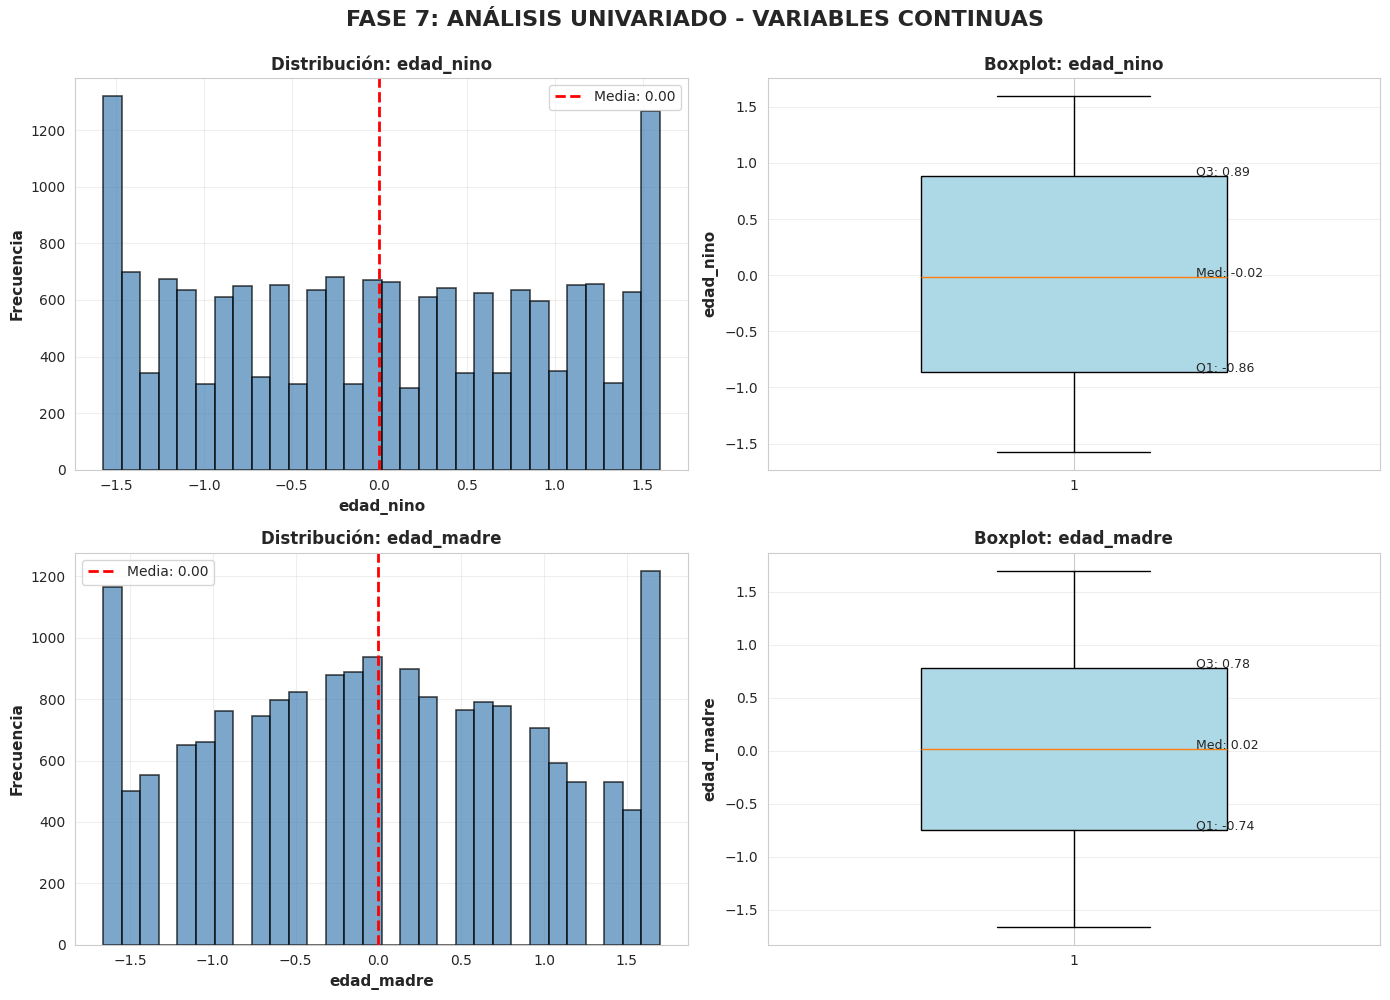

✓ Gráfico 1 completado


In [9]:
print("\n[5/8] Generando GRÁFICO 1: Distribuciones Continuas...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FASE 7: ANÁLISIS UNIVARIADO - VARIABLES CONTINUAS',
             fontsize=16, fontweight='bold', y=0.995)

for idx, var in enumerate(continuas):
    if var in df.columns:
        # HISTOGRAMA
        ax = axes[idx, 0]
        ax.hist(df[var], bins=30, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.2)
        ax.set_xlabel(var, fontsize=11, fontweight='bold')
        ax.set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
        ax.set_title(f'Distribución: {var}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Agregar línea de media
        mean_val = df[var].mean()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
        ax.legend()

        # BOXPLOT
        ax = axes[idx, 1]
        bp = ax.boxplot(df[var], vert=True, patch_artist=True, widths=0.5)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][0].set_edgecolor('black')
        ax.set_ylabel(var, fontsize=11, fontweight='bold')
        ax.set_title(f'Boxplot: {var}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        # Agregar estadísticas
        q1 = df[var].quantile(0.25)
        q3 = df[var].quantile(0.75)
        median = df[var].median()
        ax.text(1.2, q1, f'Q1: {q1:.2f}', fontsize=9)
        ax.text(1.2, median, f'Med: {median:.2f}', fontsize=9)
        ax.text(1.2, q3, f'Q3: {q3:.2f}', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Gráfico 1 completado")

In [10]:
print("\n[6/8] VARIABLES CATEGÓRICAS - DISTRIBUCIÓN")
print("-"*70)

categoricas = ['quintil_raw_3', 'quintil_raw_4', 'quintil_raw_5',
               'edu_madre_3.0', 'sexo_nino_code_2']

for var in categoricas:
    if var in df.columns:
        print(f"\n{var.upper()}:")
        counts = df[var].value_counts()
        print(f"  0: {counts.get(0, 0):,} ({counts.get(0, 0)/len(df)*100:.2f}%)")
        print(f"  1: {counts.get(1, 0):,} ({counts.get(1, 0)/len(df)*100:.2f}%)")



[6/8] VARIABLES CATEGÓRICAS - DISTRIBUCIÓN
----------------------------------------------------------------------



[7/8] Generando GRÁFICO 2: Variable Respuesta (Anemia)...


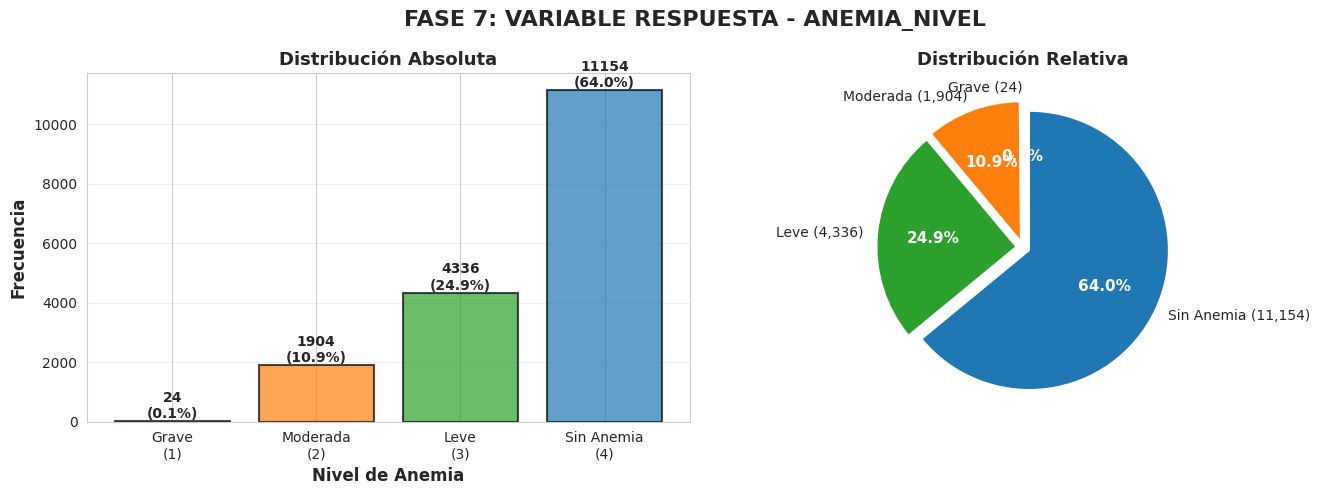

✓ Gráfico 2 completado


In [11]:
print("\n[7/8] Generando GRÁFICO 2: Variable Respuesta (Anemia)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FASE 7: VARIABLE RESPUESTA - ANEMIA_NIVEL',
             fontsize=16, fontweight='bold')

# BARPLOT
ax = axes[0]
counts = df['anemia_nivel'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax.bar(range(len(counts)), counts.values, alpha=0.7, color=colors, edgecolor='black', linewidth=1.5)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Nivel de Anemia', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('Distribución Absoluta', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(['Grave\n(1)', 'Moderada\n(2)', 'Leve\n(3)', 'Sin Anemia\n(4)'])
ax.grid(True, alpha=0.3, axis='y')

# PIE CHART
ax = axes[1]
sizes = df['anemia_nivel'].value_counts().sort_index().values
labels = [f'Grave ({sizes[0]:,})', f'Moderada ({sizes[1]:,})',
          f'Leve ({sizes[2]:,})', f'Sin Anemia ({sizes[3]:,})']
explode = (0.05, 0.05, 0.05, 0.05)

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                    startangle=90, explode=explode, textprops={'fontsize': 10})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.set_title('Distribución Relativa', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráfico 2 completado")

In [12]:
print("\n[8/8] CORRELACIÓN CON ANEMIA_NIVEL (Spearman)")
print("-"*70)

print(f"\nVariables Continuas:")

for var in continuas:
    if var in df.columns and 'anemia_nivel' in df.columns:
        corr, pval = spearmanr(df[var], df['anemia_nivel'])

        # Interpretación
        if pval < 0.001:
            sig = "*** (ALTAMENTE significativo)"
        elif pval < 0.01:
            sig = "** (MUY significativo)"
        elif pval < 0.05:
            sig = "* (Significativo)"
        else:
            sig = "ns (NO significativo)"

        print(f"\n  {var.upper()}")
        print(f"    Correlación (r): {corr:>8.4f}")
        print(f"    p-value:         {pval:>8.2e}")
        print(f"    Resultado:       {sig}")


[8/8] CORRELACIÓN CON ANEMIA_NIVEL (Spearman)
----------------------------------------------------------------------

Variables Continuas:

  EDAD_NINO
    Correlación (r):   0.3324
    p-value:         0.00e+00
    Resultado:       *** (ALTAMENTE significativo)

  EDAD_MADRE
    Correlación (r):   0.0968
    p-value:         1.44e-37
    Resultado:       *** (ALTAMENTE significativo)
